In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("data/fraudTrain.csv")
test_df = pd.read_csv("data/fraudTest.csv")

train_df['trans_date_trans_time'] = pd.to_datetime(
    train_df['trans_date_trans_time']
)

train_df['transaction_hour'] = (
    train_df['trans_date_trans_time'].dt.hour
)

train_df['transaction_day'] = (
    train_df['trans_date_trans_time'].dt.day
)

train_df['transaction_month'] = (
    train_df['trans_date_trans_time'].dt.month
)

train_df['transaction_dayofweek'] = (
    train_df['trans_date_trans_time'].dt.day_name()
)

In [27]:
month_fraud = train_df.groupby(
    'transaction_month'
)['is_fraud'].mean() * 100

print(month_fraud)

transaction_month
1     0.810679
2     0.873465
3     0.652345
4     0.502334
5     0.636596
6     0.478406
7     0.382235
8     0.437276
9     0.591632
10    0.660287
11    0.550972
12    0.419680
Name: is_fraud, dtype: float64


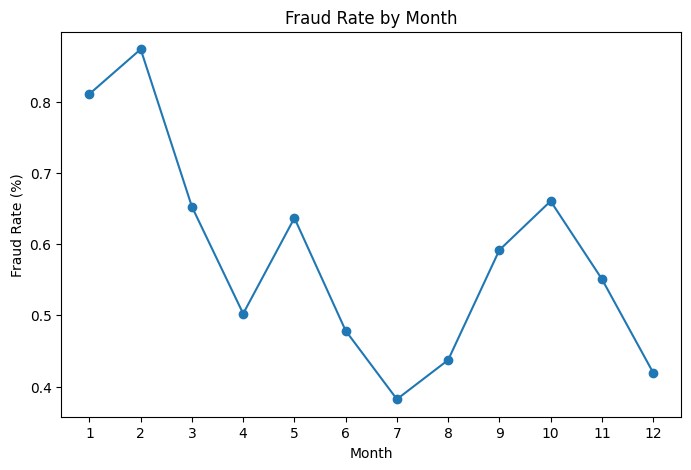

In [28]:
plt.figure(figsize=(8,5))

month_fraud.plot(
    kind='line',
    marker='o'
)

plt.title('Fraud Rate by Month')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(1, 13))

plt.show()

In [29]:
amount_analysis = train_df.groupby('is_fraud')['amt'].mean()

print(amount_analysis)

is_fraud
0     67.667110
1    531.320092
Name: amt, dtype: float64


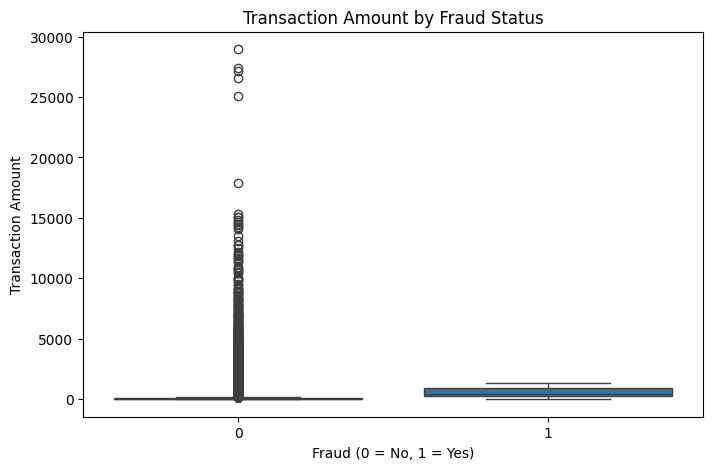

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='amt',
    data=train_df
)

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')

plt.show()

In [31]:
merchant_fraud = train_df.groupby(
    'merchant'
)['is_fraud'].mean() * 100

print(
    merchant_fraud
    .sort_values(ascending=False)
    .head(10)
)

merchant
fraud_Kozey-Boehm                       2.572347
fraud_Herman, Treutel and Dickens       2.538462
fraud_Kerluke-Abshire                   2.230686
fraud_Brown PLC                         2.210884
fraud_Goyette Inc                       2.161606
fraud_Terry-Huel                        2.154309
fraud_Jast Ltd                          2.150538
fraud_Schmeler, Bashirian and Price     2.083333
fraud_Boyer-Reichert                    1.991614
fraud_Langworth, Boehm and Gulgowski    1.980701
Name: is_fraud, dtype: float64


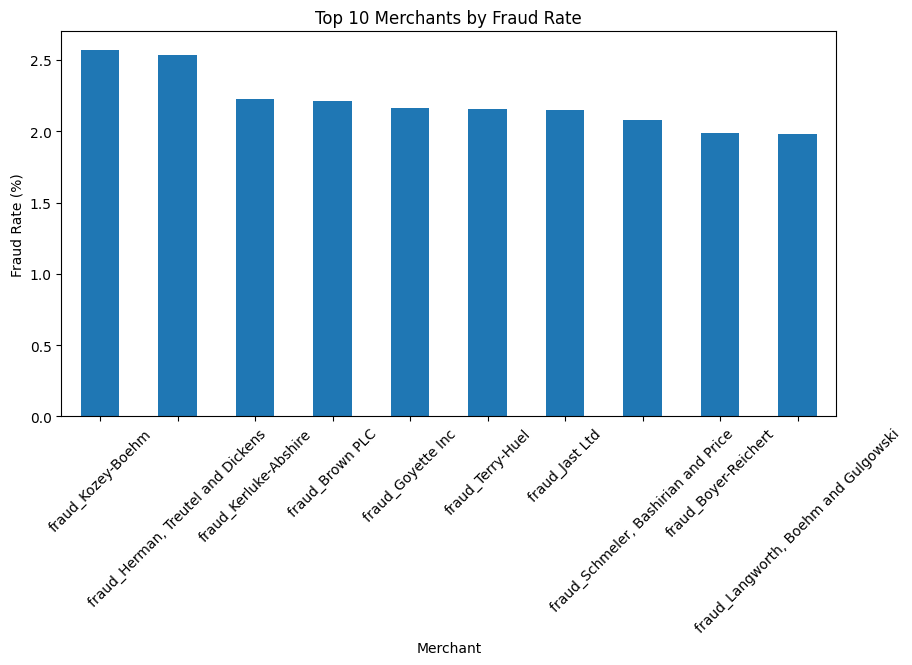

In [32]:
plt.figure(figsize=(10,5))

merchant_fraud.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top 10 Merchants by Fraud Rate')
plt.xlabel('Merchant')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [33]:
city_fraud = train_df.groupby(
    'city'
)['is_fraud'].mean() * 100

print(
    city_fraud
    .sort_values(ascending=False)
    .head(10)
)

city
Irvington    100.0
Isanti       100.0
La Grande    100.0
Wartburg     100.0
Vacaville    100.0
Waukau       100.0
Angwin       100.0
Hubbell      100.0
Lockhart     100.0
Las Vegas    100.0
Name: is_fraud, dtype: float64


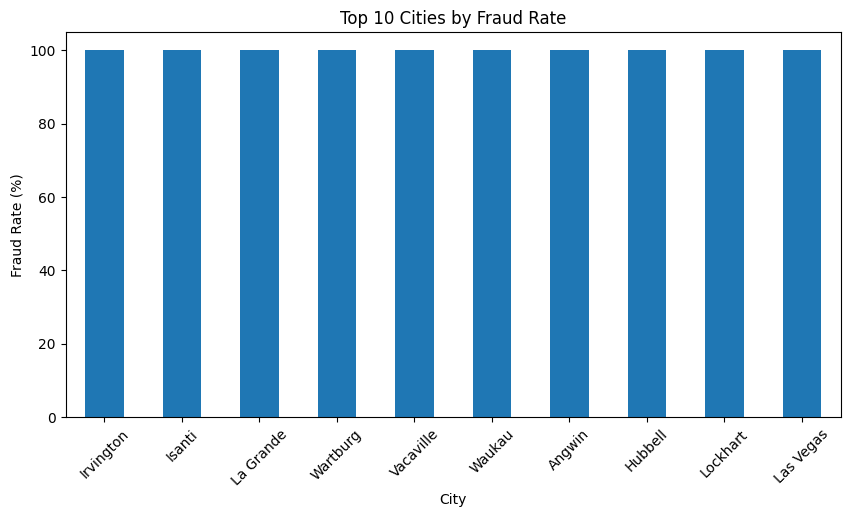

In [34]:
plt.figure(figsize=(10,5))

city_fraud.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title('Top 10 Cities by Fraud Rate')
plt.xlabel('City')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [35]:
hour_fraud = train_df.groupby(
    'transaction_hour'
)['is_fraud'].mean() * 100

print(hour_fraud)

transaction_hour
0     1.494047
1     1.534909
2     1.465210
3     1.423929
4     0.109882
5     0.142278
6     0.094563
7     0.132692
8     0.115281
9     0.111414
10    0.094628
11    0.099805
12    0.102671
13    0.122485
14    0.132542
15    0.120812
16    0.115632
17    0.119175
18    0.122633
19    0.123649
20    0.095241
21    0.112920
22    2.882864
23    2.837387
Name: is_fraud, dtype: float64


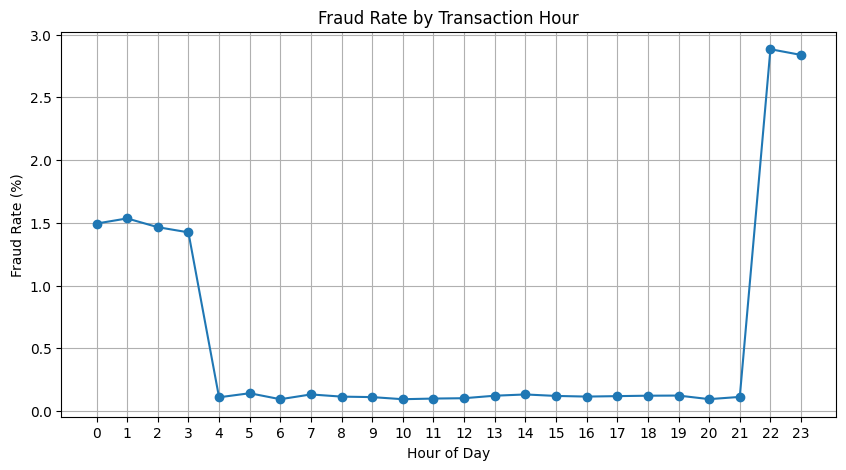

In [36]:
plt.figure(figsize=(10,5))

hour_fraud.plot(
    kind='line',
    marker='o'
)

plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(24))
plt.grid()

plt.show()